## **ÁRBOLES DE DECISIÓN**

Un árbol de decisión es un modelo de aprendizaje automático que funciona como un diagrama de flujo. Divide los datos en grupos cada vez más pequeños basándose en reglas condicionales (si/entonces) para predecir un resultado.El objetivo principal es crear divisiones que resulten en nodos lo más "puros" posibles, es decir, donde la mayoría de los datos pertenezcan a una sola categoría. Para medir esta pureza, se utilizan métricas como la Entropía y el Índice Gini.

La entropía mide el grado de desorden, caos o incertidumbre en un conjunto de datos.Si un nodo contiene datos perfectamente mezclados al 50/50, la entropía es máxima (1).Si todos los datos pertenecen a una sola clase, la entropía es mínima (0).

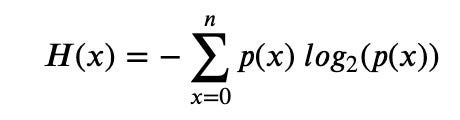


La impureza de Gini (Gini Impurity) mide la probabilidad de clasificar incorrectamente un elemento elegido al azar si se le asignara una etiqueta aleatoria basada en la distribución de clases del nodo. Varía entre 0 (pureza total) y 0.5 (máxima impureza en una clasificación binaria). Es computacionalmente más rápida de calcular que la entropía porque no utiliza logaritmos.

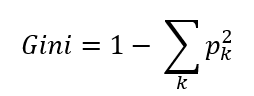

Importar librerías

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import random

from sklearn.datasets import load_iris #Conjunto de datos Iris
from sklearn.model_selection import train_test_split #Para partición del conjunto de datos en entrenamiento y prueba
from sklearn import tree #Modelo de árboles de decisión
from sklearn.preprocessing import LabelEncoder #Para convertir etiquetas
from sklearn.metrics import mean_absolute_error, mean_squared_error #Para validación con cálculo de errores en predicciones
from sklearn.metrics import ConfusionMatrixDisplay #Matriz de confusión (para validación)

Cargar conjunto de datos

In [3]:
#Cargar conjunto de datos
iris = load_iris()

#Convertir a pandas (dataframe - df)
iris_features = pd.DataFrame(data=iris.data, columns=iris.feature_names) #Características X

Definir entradas como matriz X

In [4]:
X = iris_features.copy()
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Codificar variables categóricas (nombres de especies) en variables numéricas (0, 1 o 2)

In [5]:
le = LabelEncoder()
encod = le.fit_transform(iris.target_names)
print(encod)

[0 1 2]


Partir el conjunto de datos en entrenamiento (66%) y validación (33%)

El parámetro "random_state" sirve para controlar la aleatoriedad y siempre, aunque aleatoria, hacer la partición de la misma manera, lo cual es útil para hacer la partición en diferentes simulaciones y con diferentes modelos con la misma partición.

In [16]:
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=101)
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train: ', y_train.shape)
print('y_test: ', y_test.shape)

X_train:  (100, 4)
X_test:  (50, 4)
y_train:  (100,)
y_test:  (50,)


Modelo

In [23]:
dt1 = tree.DecisionTreeClassifier(criterion='entropy') #Se define modelo lineal con Entropía
dt1.fit(X_train, y_train) #Se entrena el modelo con el subconjunto "train"

DecisionTreeClassifier(criterion='entropy')

Se realizan predicciones sobre el subconjunto de validación (test) que no participó durante el entrenamiento.

In [24]:
pred = dt1.predict(X_test)
print(pred)

[0 0 0 1 1 2 1 1 2 0 2 0 0 2 2 1 1 1 0 2 1 0 1 1 1 1 1 2 0 0 2 1 2 1 2 1 1
 1 1 2 0 0 0 2 1 0 2 1 0 1]


Validar

In [28]:
print('MSE:', mean_squared_error(y_test, pred))

MSE: 0.04


Modificar hiperarámetros para tratar de mejorar el modelo

In [31]:
dt2 = tree.DecisionTreeClassifier(criterion='gini', min_samples_split=4) #Se define modelo lineal con criterio Gini y mínimas muestras para partir un nodo interno en 4
dt2.fit(X_train, y_train) #Se entrena el modelo con el subconjunto "train"
pred = dt2.predict(X_test)
print('MSE:', mean_squared_error(y_test, pred))

MSE: 0.02


Se modificaron los hiperparámetros y con ello el error del modelo se reduce.

Se muestra el árbol con mejor desempeño

[Text(0.375, 0.9, 'x[2] <= 2.6\ngini = 0.662\nsamples = 100\nvalue = [35.0, 28.0, 37.0]'),
 Text(0.25, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.3125, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[3] <= 1.65\ngini = 0.49\nsamples = 65\nvalue = [0, 28, 37]'),
 Text(0.4375, 0.8, '  False'),
 Text(0.25, 0.5, 'x[2] <= 4.95\ngini = 0.128\nsamples = 29\nvalue = [0, 27, 2]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 26\nvalue = [0, 26, 0]'),
 Text(0.375, 0.3, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.75, 0.5, 'x[2] <= 4.85\ngini = 0.054\nsamples = 36\nvalue = [0, 1, 35]'),
 Text(0.625, 0.3, 'x[1] <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.75, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 32\nvalue = [0, 0, 32]')]

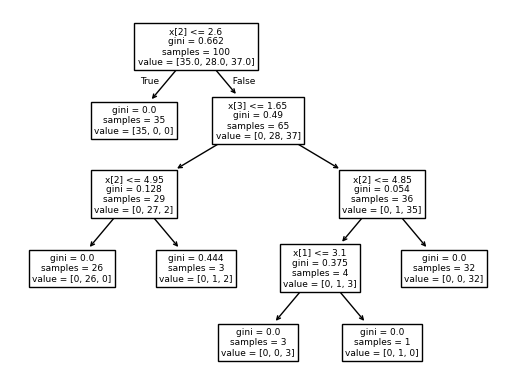

In [32]:
tree.plot_tree(dt2)

En la gráfica del arbol se ve que inicia con 35, 28 y 37 muestras y que después de definir la tercera característica "longitud del pétalo" (X[2]<=2.6) hace la primera división de nodo generando una hoja pura por la izquierda con 35 muestras de setosa, y quedando en la derecha 28 y 37 de versicolor y virginica.

Luego esta rama la divide nuevamente usando X[3]<=1.65 "ancho del pétalo" y asi sucesivamente hasta llegar a Gini=0 en todas las hojas, excepto en una que fue de 0.444